In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/predicted_human_tfs.csv")

# columns: seq_id, motif_name, random_seq, predictions

# Filter to just those motif names we're interested in
df_alt = df[df["motif_name"].str.endswith("_alt")].copy()
df_ref = df[~df["motif_name"].str.endswith("_alt")].copy()

# Strip "_alt" to match the base motif name
df_alt["base_motif"] = df_alt["motif_name"].str.replace("_alt", "", regex=False)
df_ref["base_motif"] = df_ref["motif_name"]

# Merge on seq_id and base_motif
merged = pd.merge(
    df_ref,
    df_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)

# Compute the variant effect difference
merged["variant_effect"] = merged["predictions_ref"] - merged["predictions_alt"]


In [3]:
len(merged)

4500

In [4]:
merged = merged[~merged['base_motif'].str.contains("MOUSE", case=False, na=False)]


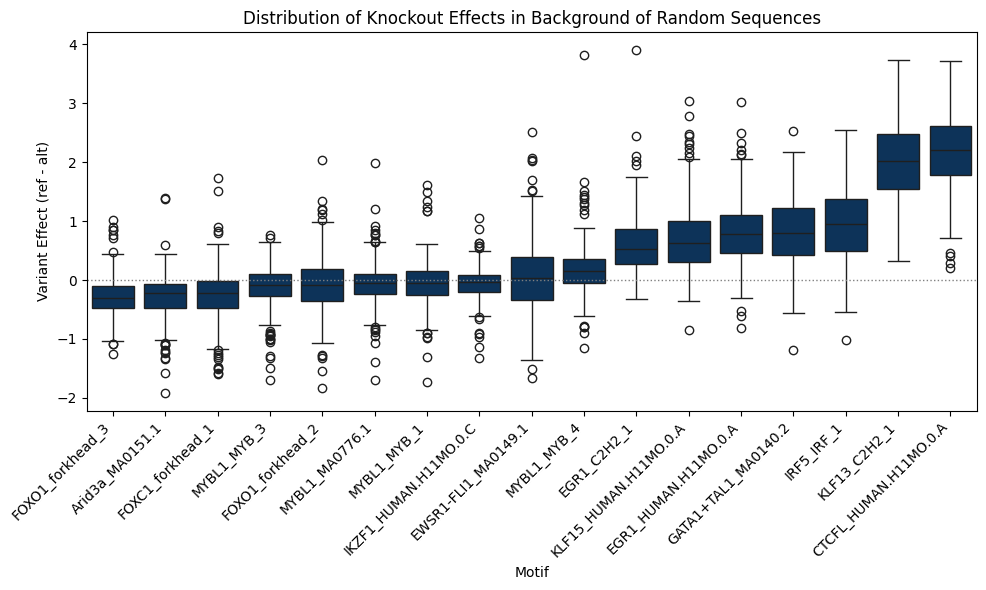

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute medians per motif
order = (
    merged.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged,
    x="base_motif",
    y="variant_effect",
    order=order,  # <- Apply sorted order
    color='#003366'
)

# Add horizontal dotted line at y=0
plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Variant Effect (ref - alt)")
plt.xlabel("Motif")
plt.title("Distribution of Knockout Effects in Background of Random Sequences")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_all_variants.svg", format="svg")
plt.show()


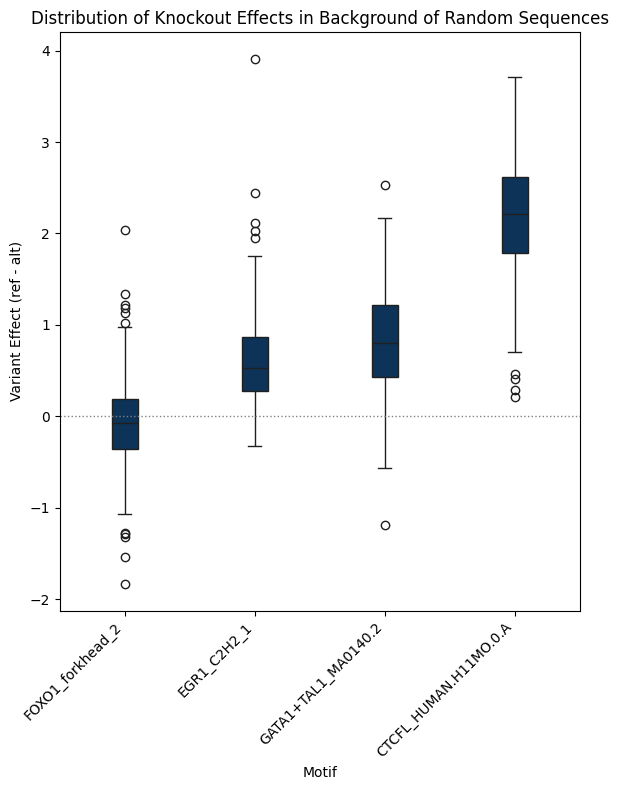

In [6]:
filters = [
    ("CTCFL_HUMAN.H11MO.0.A"),
    ("EGR1_C2H2_1"),
    ("GATA1+TAL1_MA0140.2"),
    ("FOXO1_forkhead_2")
]

# Convert to DataFrame for easy filtering
filter_df = pd.DataFrame(filters, columns=["base_motif"])

# Merge to get only the filtered motifs
filtered = pd.merge(
    merged,
    filter_df,
    on=["base_motif"]
)

# Sort by median variant effect
order = (
    filtered.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

plt.figure(figsize=(6, 8))
sns.boxplot(
    data=filtered,
    x="base_motif",
    y="variant_effect",
    order=order,  # Apply sorted order
    color='#003366',
    width=0.2
)

plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Variant Effect (ref - alt)")
plt.xlabel("Motif")
plt.title("Distribution of Knockout Effects in Background of Random Sequences")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_k562_variants.svg", format="svg")
plt.show()


### Repeating this for the motifs in enhancers

In [7]:
df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/predicted_human_tfs_enhancer.csv", sep="\t")

# columns: seq_id, motif_name, random_seq, predictions

# Filter to just those motif names we're interested in
df_alt = df[df["motif_name"].str.endswith("_alt")].copy()
df_ref = df[~df["motif_name"].str.endswith("_alt")].copy()

# Strip "_alt" to match the base motif name
df_alt["base_motif"] = df_alt["motif_name"].str.replace("_alt", "", regex=False)
df_ref["base_motif"] = df_ref["motif_name"]

# Merge on seq_id and base_motif
merged = pd.merge(
    df_ref,
    df_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)

# Compute the variant effect difference
merged["variant_effect"] = merged["predictions_ref"] - merged["predictions_alt"]
merged = merged[~merged['base_motif'].str.contains("MOUSE", case=False, na=False)]



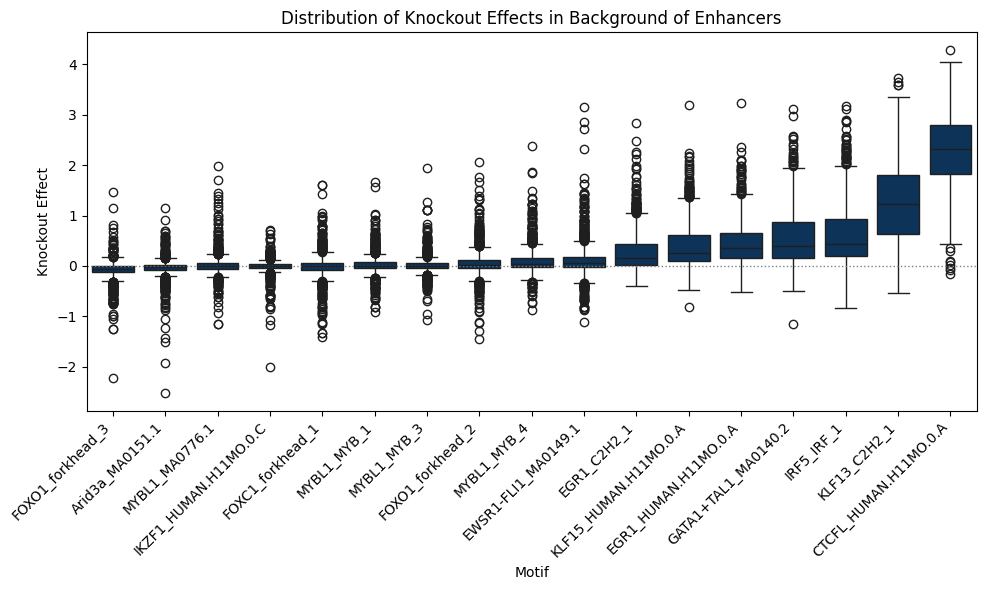

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute medians per motif
order = (
    merged.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged,
    x="base_motif",
    y="variant_effect",
    order=order,  
    color='#003366'
)

# Add horizontal dotted line at y=0
plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Knockout Effect")
plt.xlabel("Motif")
plt.title("Distribution of Knockout Effects in Background of Enhancers")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_all_variants_enhancers.svg", format="svg")
plt.show()


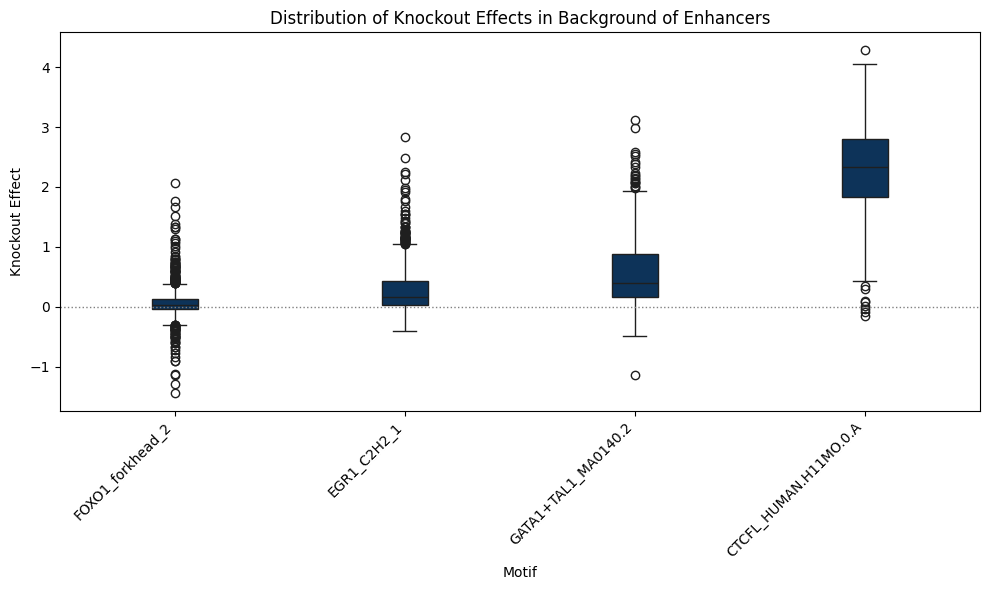

In [9]:
filters = [
    ("CTCFL_HUMAN.H11MO.0.A"),
    ("EGR1_C2H2_1"),
    ("GATA1+TAL1_MA0140.2"),
    ("FOXO1_forkhead_2")
]

# Convert to DataFrame for easy filtering
filter_df = pd.DataFrame(filters, columns=["base_motif"])

# Merge to get only the filtered motifs
filtered = pd.merge(
    merged,
    filter_df,
    on=["base_motif"]
)

# Sort by median variant effect
order = (
    filtered.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered,
    x="base_motif",
    y="variant_effect",
    order=order,  # Apply sorted order
    color='#003366',
    width=0.2
)

plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Knockout Effect")
plt.xlabel("Motif")
plt.title("Distribution of Knockout Effects in Background of Enhancers")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_k562_variants_enhancers.svg", format="svg")
plt.show()


### Plotting them in same plot

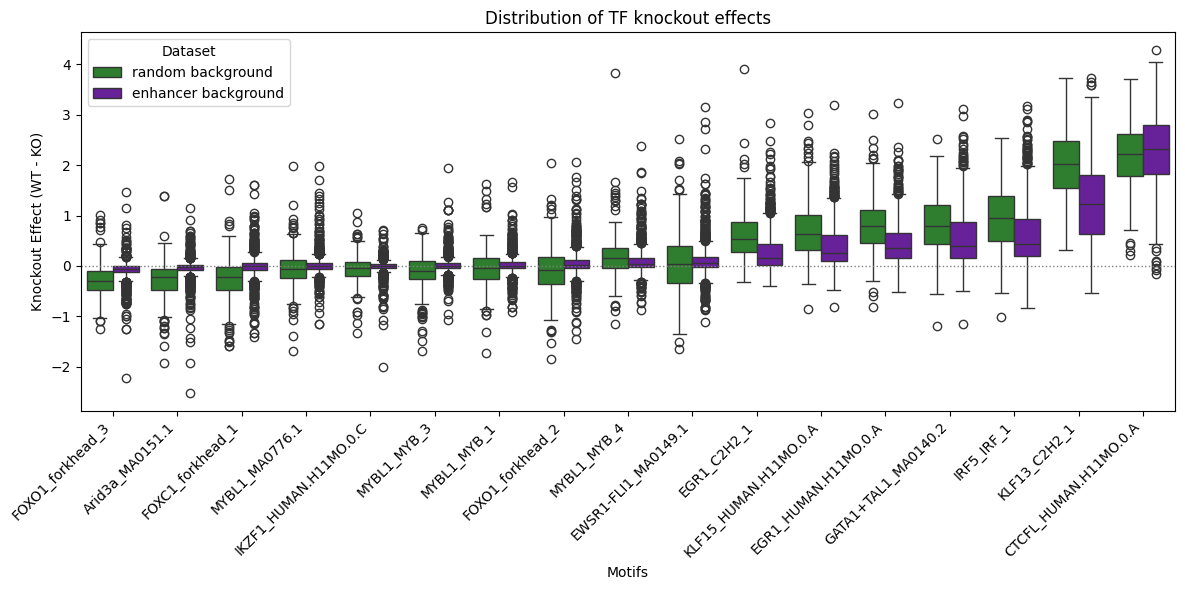

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the first dataset (already processed)
df1 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/predicted_human_tfs.csv")
df1_alt = df1[df1["motif_name"].str.endswith("_alt")].copy()
df1_ref = df1[~df1["motif_name"].str.endswith("_alt")].copy()
df1_alt["base_motif"] = df1_alt["motif_name"].str.replace("_alt", "", regex=False)
df1_ref["base_motif"] = df1_ref["motif_name"]

merged1 = pd.merge(
    df1_ref,
    df1_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)
merged1["variant_effect"] = merged1["predictions_ref"] - merged1["predictions_alt"]
merged1 = merged1[~merged1['base_motif'].str.contains("MOUSE", case=False, na=False)]
merged1["dataset"] = "random background"

# Load the second dataset (enhancer)
df2 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/predicted_human_tfs_enhancer.csv", sep="\t")
df2_alt = df2[df2["motif_name"].str.endswith("_alt")].copy()
df2_ref = df2[~df2["motif_name"].str.endswith("_alt")].copy()
df2_alt["base_motif"] = df2_alt["motif_name"].str.replace("_alt", "", regex=False)
df2_ref["base_motif"] = df2_ref["motif_name"]

merged2 = pd.merge(
    df2_ref,
    df2_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)
merged2["variant_effect"] = merged2["predictions_ref"] - merged2["predictions_alt"]
merged2 = merged2[~merged2['base_motif'].str.contains("MOUSE", case=False, na=False)]
merged2["dataset"] = "enhancer background"

# Combine the two
combined = pd.concat([merged1, merged2], axis=0, ignore_index=True)

# Optional: define order by median across both datasets
order = (
    combined.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=combined,
    x="base_motif",
    y="variant_effect",
    hue="dataset",          # Color by dataset
    order=order,
    palette={"random background": "#228B22", "enhancer background": "#6A0DAD"}
)

plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Knockout Effect (WT - KO)")
plt.xlabel("Motifs")
plt.title("Distribution of TF knockout effects")
plt.legend(title="Dataset")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_combined.svg", format="svg")
plt.show()


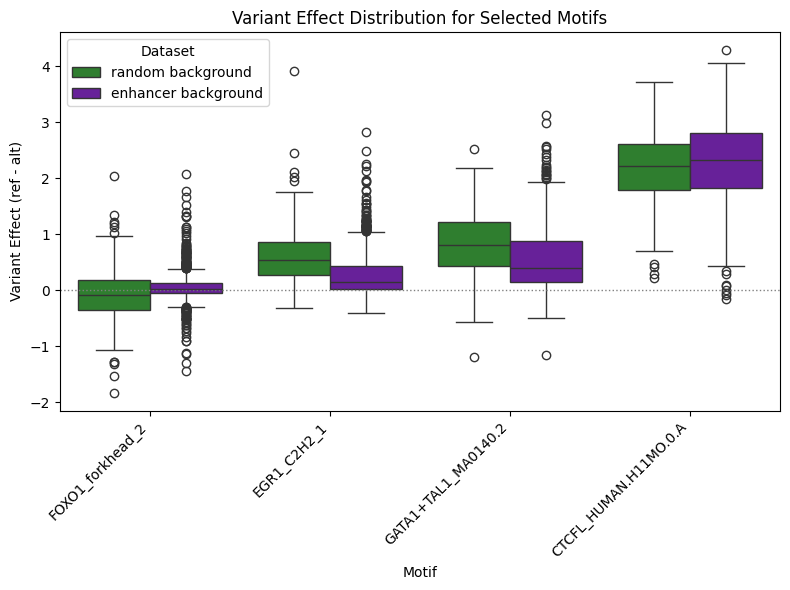

In [11]:
# Define the motifs to keep
filters = [
    "CTCFL_HUMAN.H11MO.0.A",
    "EGR1_C2H2_1",
    "GATA1+TAL1_MA0140.2",
    "FOXO1_forkhead_2"
]

# Filter the combined dataframe
filtered_combined = combined[combined["base_motif"].isin(filters)].copy()

# Optional: keep the same median-based order for these motifs
order_filtered = (
    filtered_combined.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=filtered_combined,
    x="base_motif",
    y="variant_effect",
    hue="dataset",
    order=order_filtered,
    palette={"random background": "#228B22", "enhancer background": "#6A0DAD"}
)

plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Variant Effect (ref - alt)")
plt.xlabel("Motif")
plt.title("Variant Effect Distribution for Selected Motifs")
plt.legend(title="Dataset")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/selected_TFs.svg", format="svg")

plt.show()
